# COMSOL PFF Simulation Analysis

This notebook analyses the outputs of COMSOL numerical simulations for the **Pinched Flow Fractionation (PFF)** module.

Two device designs are compared:
- **80 µm** pinched segment width
- **160 µm** pinched segment width

Both designs have 3 outlet branches (1 waste, 1 collection). The sample inlet flow rate is fixed at **12 µL/h**, and the wash inlet flow rate is varied parametrically.

---

**Notebook structure:**
1. Setup & data loading
2. KDE distributions — all flow rates overlaid
3. KDE distributions — grid per flow rate (appendix)
4. Separation threshold *d★* vs wash flow rate
5. Separation metrics vs wash flow rate
6. Export summary tables

---
## 1. Setup & data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from pathlib import Path
import math

# ── Minimal rcParams: only structural defaults, no font sizes ─────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
})

# ── Colour scheme ─────────────────────────────────────────────────────────────
COL_COLLECTION = "#E8720C"   # orange  — collection outlet
COL_WASTE      = "#555555"   # dark grey — waste outlet

# Design line styles (KDE overlaid plots): solid = 160 µm, dashed = 80 µm
DESIGN_STYLE = {
    "80um_3out":  {"linestyle": "--", "label": "80 µm"},
    "160um_3out": {"linestyle": "-",  "label": "160 µm"},
}

# Design colours (d★ and metrics plots) — colour-blind safe (Wong palette)
DESIGN_COLOR = {
    "80um_3out":  "#CC79A7",   # pink/mauve
    "160um_3out": "#003366",   # dark blue — matches thesis palette
}

# Explicit design order (avoid alphabetical sorting artefacts)
designs = ["80um_3out", "160um_3out"]

# Wash flow rates used in the parametric sweep (µL/h)
WASH_FLOW_RATES  = [12, 22, 31, 40, 50, 73, 97, 144, 191, 237]
SAMPLE_FLOW_RATE = 12   # µL/h, fixed
ARTEFACT_FLOW    = 12   # flow_wash == 12 => flow ratio = 1, no separation

print("Setup complete.")

Setup complete.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

ROOT_COMSOL = Path("/content/drive/MyDrive/Colab Notebooks/MEP/COMSOL_PFF_simulations")

# ── Load all simulation files ─────────────────────────────────────────────────
all_sim = []

for file in ROOT_COMSOL.glob("*.txt"):
    name  = file.stem
    parts = name.split("_")

    pinched = int(parts[0].replace("con", ""))
    outlets = int(parts[1].replace("out", ""))
    v1      = int(parts[2])   # sample flow rate (µL/h), fixed at 12
    v2      = int(parts[3])   # wash flow rate (µL/h), varied

    df = pd.read_csv(file, comment="%", sep=r"\s+")
    df.columns = ["particle_id", "outlet", "diameter"]

    df["pinched_width"] = pinched
    df["outlets"]       = outlets
    df["flow_sample"]   = v1
    df["flow_wash"]     = v2

    all_sim.append(df)

comsol_df = pd.concat(all_sim, ignore_index=True)

# Remove particles that did not exit through a valid outlet (outlet == -1)
comsol_df = comsol_df[comsol_df["outlet"] != -1].copy()

# Design label and outlet label
comsol_df["design"] = (
    comsol_df["pinched_width"].astype(str) + "um_" +
    comsol_df["outlets"].astype(str) + "out"
)
comsol_df["outlet_label"] = comsol_df["outlet"].map({0: "Waste", 1: "Collection"})

wash_rates = sorted(comsol_df["flow_wash"].unique())
n_rates    = len(wash_rates)

print(f"Loaded {len(comsol_df):,} particle records.")
print(f"Designs:    {designs}")
print(f"Wash rates: {wash_rates} µL/h")
comsol_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 21,703 particle records.
Designs:    ['80um_3out', '160um_3out']
Wash rates: [np.int64(12), np.int64(22), np.int64(31), np.int64(40), np.int64(50), np.int64(73), np.int64(97), np.int64(144), np.int64(191), np.int64(237), np.int64(261)] µL/h


,particle_id,outlet,diameter,pinched_width,outlets,flow_sample,flow_wash,design,outlet_label
0,2,1.0,29.684340,80,3,12,144,80um_3out,Collection
1,3,0.0,5.888626,80,3,12,144,80um_3out,Waste
2,4,0.0,22.333244,80,3,12,144,80um_3out,Waste
3,5,0.0,15.829075,80,3,12,144,80um_3out,Waste
4,6,0.0,13.918732,80,3,12,144,80um_3out,Waste


---
## 2. KDE distributions — all flow rates overlaid

Two figures: one for the waste outlet, one for the collection outlet.  
Each figure shows both designs side by side.  
Curves are colour-coded by wash flow rate; solid line = 160 µm, dashed = 80 µm.  
Y-axis limits are consistent across both figures within each outlet type.

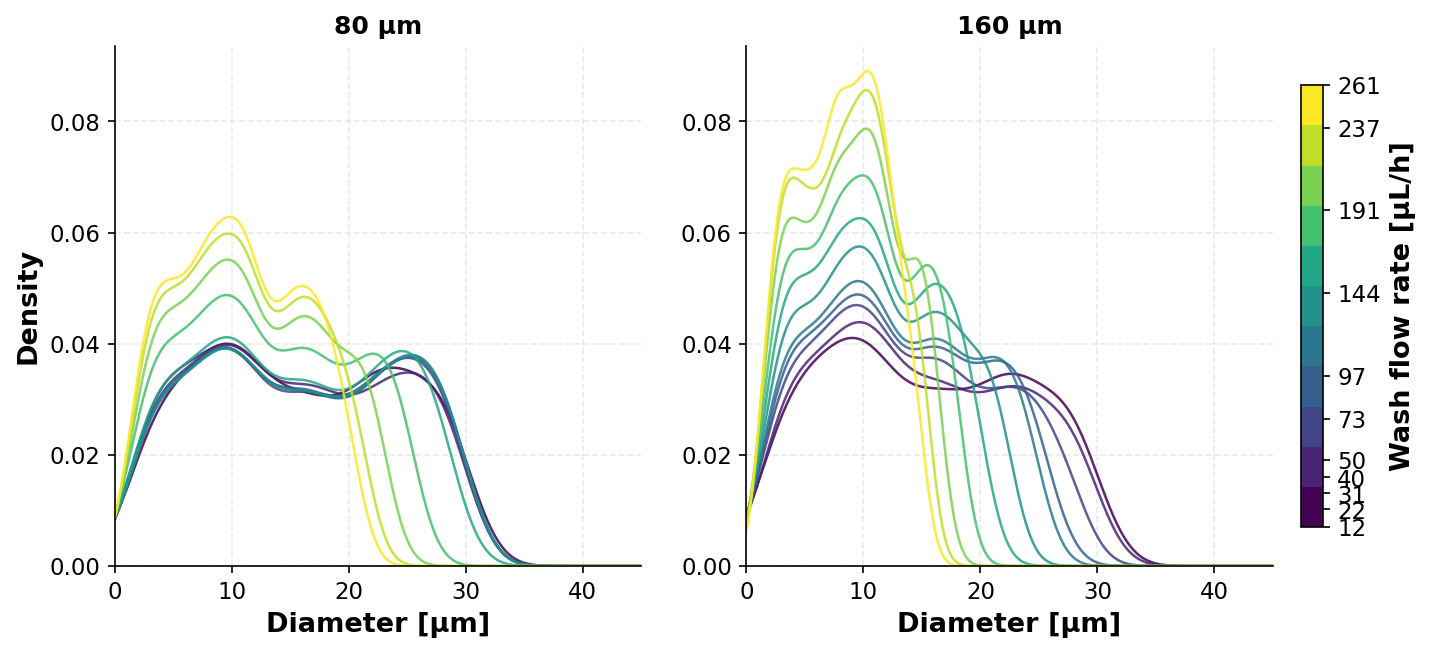

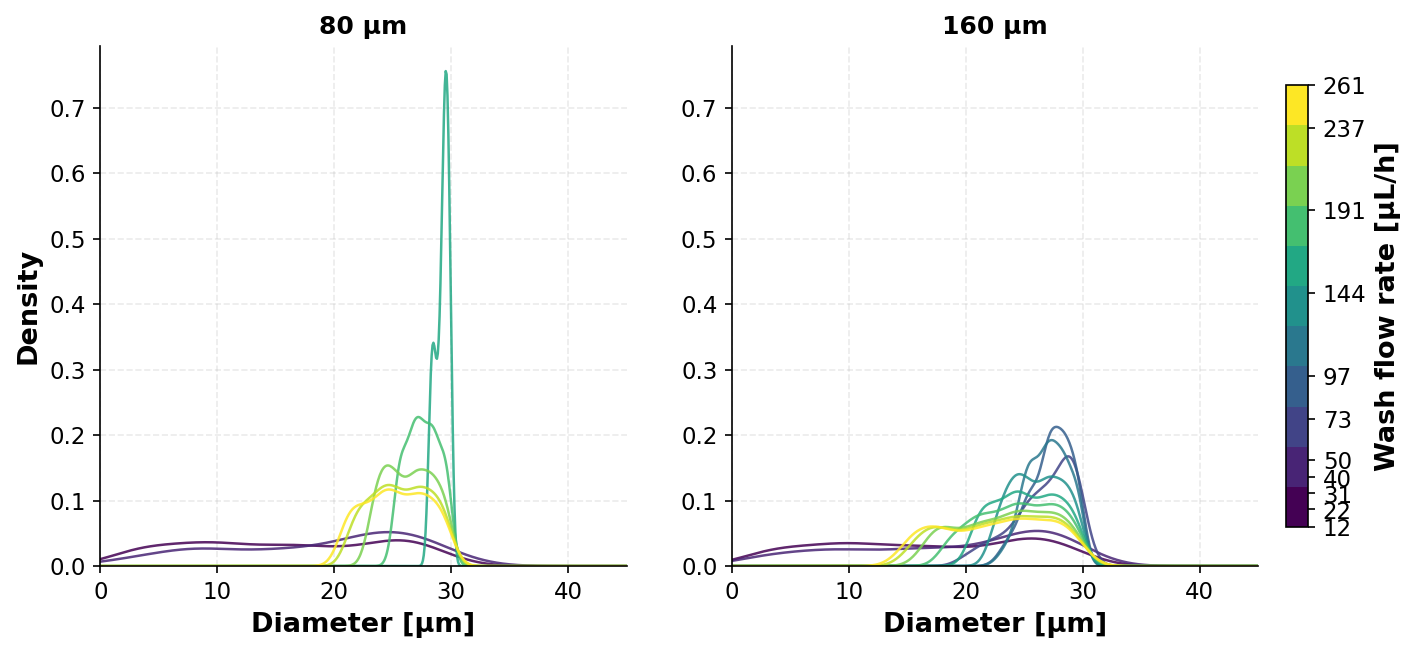

In [ ]:
cmap        = matplotlib.colormaps["viridis"].resampled(n_rates)
rate_colors = {v2: cmap(i) for i, v2 in enumerate(wash_rates)}

x_eval = np.linspace(0, 45, 600)
X_LIM  = (0, 45)

# ── Pre-compute y-axis limits across both designs ─────────────────────────────
y_max_waste   = 0
y_max_collect = 0

for design in designs:
    df_d = comsol_df[comsol_df["design"] == design]
    for v2 in wash_rates:
        df_v = df_d[df_d["flow_wash"] == v2]
        waste = df_v[df_v["outlet"] == 0]["diameter"].values
        coll  = df_v[df_v["outlet"] == 1]["diameter"].values
        if len(waste) > 1:
            y_max_waste = max(y_max_waste, gaussian_kde(waste)(x_eval).max())
        if len(coll) > 1:
            y_max_collect = max(y_max_collect, gaussian_kde(coll)(x_eval).max())

Y_LIM_WASTE   = (0, y_max_waste   * 1.05)
Y_LIM_COLLECT = (0, y_max_collect * 1.05)

# ── Shared colorbar setup ─────────────────────────────────────────────────────
def add_colorbar(fig, axes, cmap, wash_rates):
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=min(wash_rates), vmax=max(wash_rates))
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
    cbar.set_ticks(wash_rates)
    cbar.ax.tick_params(labelsize=11)

# ── Shared legend setup ───────────────────────────────────────────────────────
def add_design_legend(ax):
    handles = [
        Line2D([0], [0], color="black",
               linestyle=DESIGN_STYLE[d]["linestyle"],
               linewidth=1.5, label=DESIGN_STYLE[d]["label"])
        for d in designs
    ]
    ax.legend(handles=handles, title="Pinched width",
              title_fontsize=11, fontsize=11,
              loc="upper right", framealpha=0.8)

# ── Figure 1: Waste outlet ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, design in zip(axes, designs):
    df_d = comsol_df[comsol_df["design"] == design]
    for v2 in wash_rates:
        df_v  = df_d[df_d["flow_wash"] == v2]
        waste = df_v[df_v["outlet"] == 0]["diameter"].values
        if len(waste) > 1:
            kde = gaussian_kde(waste)
            ax.plot(x_eval, kde(x_eval), color=rate_colors[v2],
                    #linestyle=DESIGN_STYLE[design]["linestyle"],
                    linewidth=1.2, alpha=0.85)
    ax.set_title(DESIGN_STYLE[design]["label"], fontsize=12, fontweight="bold")
    ax.set_xlabel("Diameter [µm]", fontsize=13, fontweight="bold")
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM_WASTE)
    ax.tick_params(labelsize=11)

axes[0].set_ylabel("Density", fontsize=13, fontweight="bold")
add_colorbar(fig, axes, cmap, wash_rates)
#add_design_legend(axes[0])

#fig.suptitle(
#    f"KDE diameter distributions — Waste outlet\n",
#    fontsize=13)

#plt.tight_layout()
plt.savefig("fig_kde_overlaid_waste.pdf", bbox_inches="tight")
plt.show()

# ── Figure 2: Collection outlet ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, design in zip(axes, designs):
    df_d = comsol_df[comsol_df["design"] == design]
    for v2 in wash_rates:
        df_v = df_d[df_d["flow_wash"] == v2]
        coll = df_v[df_v["outlet"] == 1]["diameter"].values
        if len(coll) > 1:
            kde = gaussian_kde(coll)
            ax.plot(x_eval, kde(x_eval), color=rate_colors[v2],
                    #linestyle=DESIGN_STYLE[design]["linestyle"],
                    linewidth=1.2, alpha=0.85)
    ax.set_title(DESIGN_STYLE[design]["label"], fontsize=12, fontweight="bold")
    ax.set_xlabel("Diameter [µm]", fontsize=13, fontweight="bold")
    ax.set_xlim(X_LIM)
    ax.set_ylim(Y_LIM_COLLECT)
    ax.tick_params(labelsize=11)

axes[0].set_ylabel("Density", fontsize=13, fontweight="bold")
add_colorbar(fig, axes, cmap, wash_rates)
#add_design_legend(axes[0])

#fig.suptitle(
#    f"KDE diameter distributions — Collection outlet\n",
#    fontsize=13)

#plt.tight_layout()
plt.savefig("fig_kde_overlaid_collection.pdf", bbox_inches="tight")
plt.show()

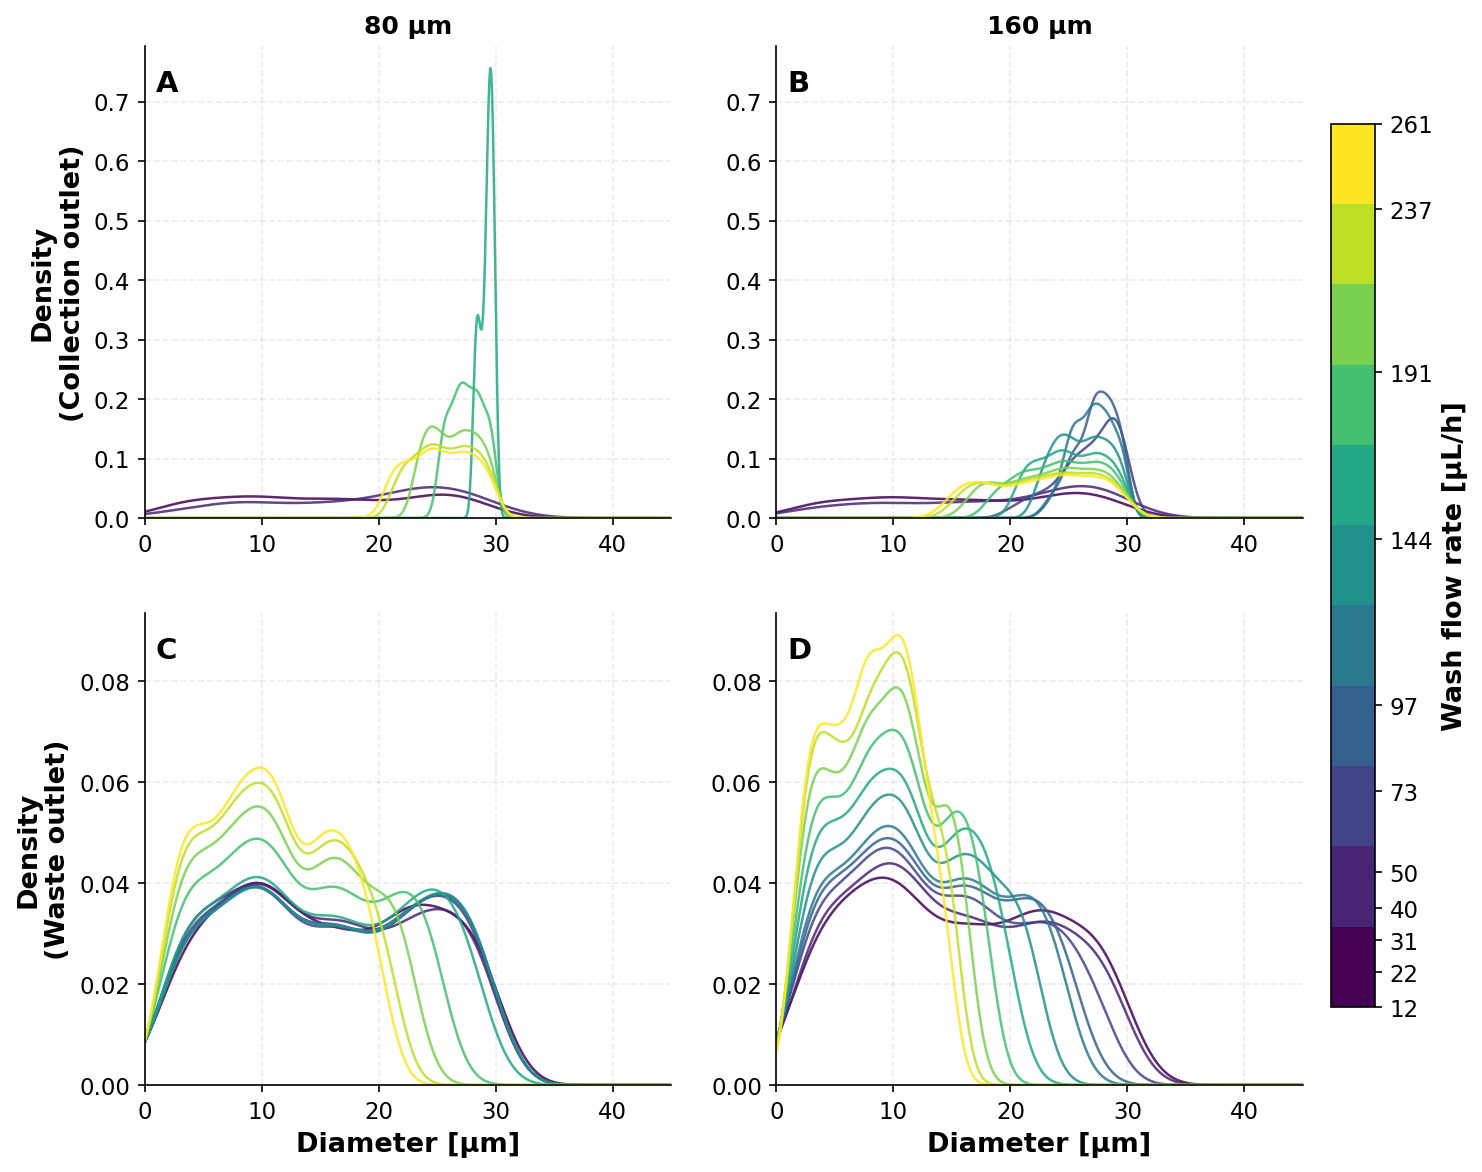

In [ ]:
# ── Combined figure: Waste (top row) + Collection (bottom row) ────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Configuration for each row: (outlet code, y-limit, row label)
rows = [
    (1, Y_LIM_COLLECT, "Collection outlet"),
    (0, Y_LIM_WASTE,   "Waste outlet"),
]

# Panel labels (A) (B) (C) (D)
panel_labels = [["A", "B"], ["C", "D"]]

for row_idx, (outlet_code, y_lim, row_label) in enumerate(rows):
    for col_idx, design in enumerate(designs):
        ax   = axes[row_idx, col_idx]
        df_d = comsol_df[comsol_df["design"] == design]

        for v2 in wash_rates:
            df_v = df_d[df_d["flow_wash"] == v2]
            data = df_v[df_v["outlet"] == outlet_code]["diameter"].values
            if len(data) > 1:
                kde = gaussian_kde(data)
                ax.plot(x_eval, kde(x_eval), color=rate_colors[v2],
                        linewidth=1.2, alpha=0.85)

        # Panel label (A, B, C, D) in the top-left corner
        ax.text(0.02, 0.95, panel_labels[row_idx][col_idx],
                transform=ax.transAxes,
                fontsize=14, fontweight="bold",
                va="top", ha="left")

        # Design title only on top row
        if row_idx == 0:
            ax.set_title(DESIGN_STYLE[design]["label"],
                         fontsize=12, fontweight="bold")

        # X-label only on bottom row
        if row_idx == len(rows) - 1:
            ax.set_xlabel("Diameter [µm]", fontsize=13, fontweight="bold")

        # Y-label only on leftmost column, including outlet identification
        if col_idx == 0:
            ax.set_ylabel(f"Density\n({row_label})",
                          fontsize=13, fontweight="bold")

        ax.set_xlim(X_LIM)
        ax.set_ylim(y_lim)
        ax.tick_params(labelsize=11)

# Single shared colorbar for all four panels
add_colorbar(fig, axes.ravel().tolist(), cmap, wash_rates)

plt.savefig("fig_kde_overlaid_combined.pdf", bbox_inches="tight")
plt.show()

---
## 3. KDE distributions — grid per flow rate (appendix)

One subplot per wash flow rate. Each subplot shows 4 KDE curves:  
waste (grey) and collection (orange) for each design (solid = 160 µm, dashed = 80 µm).  
The KDE intersection threshold *d★* is shown as a vertical dashed line.

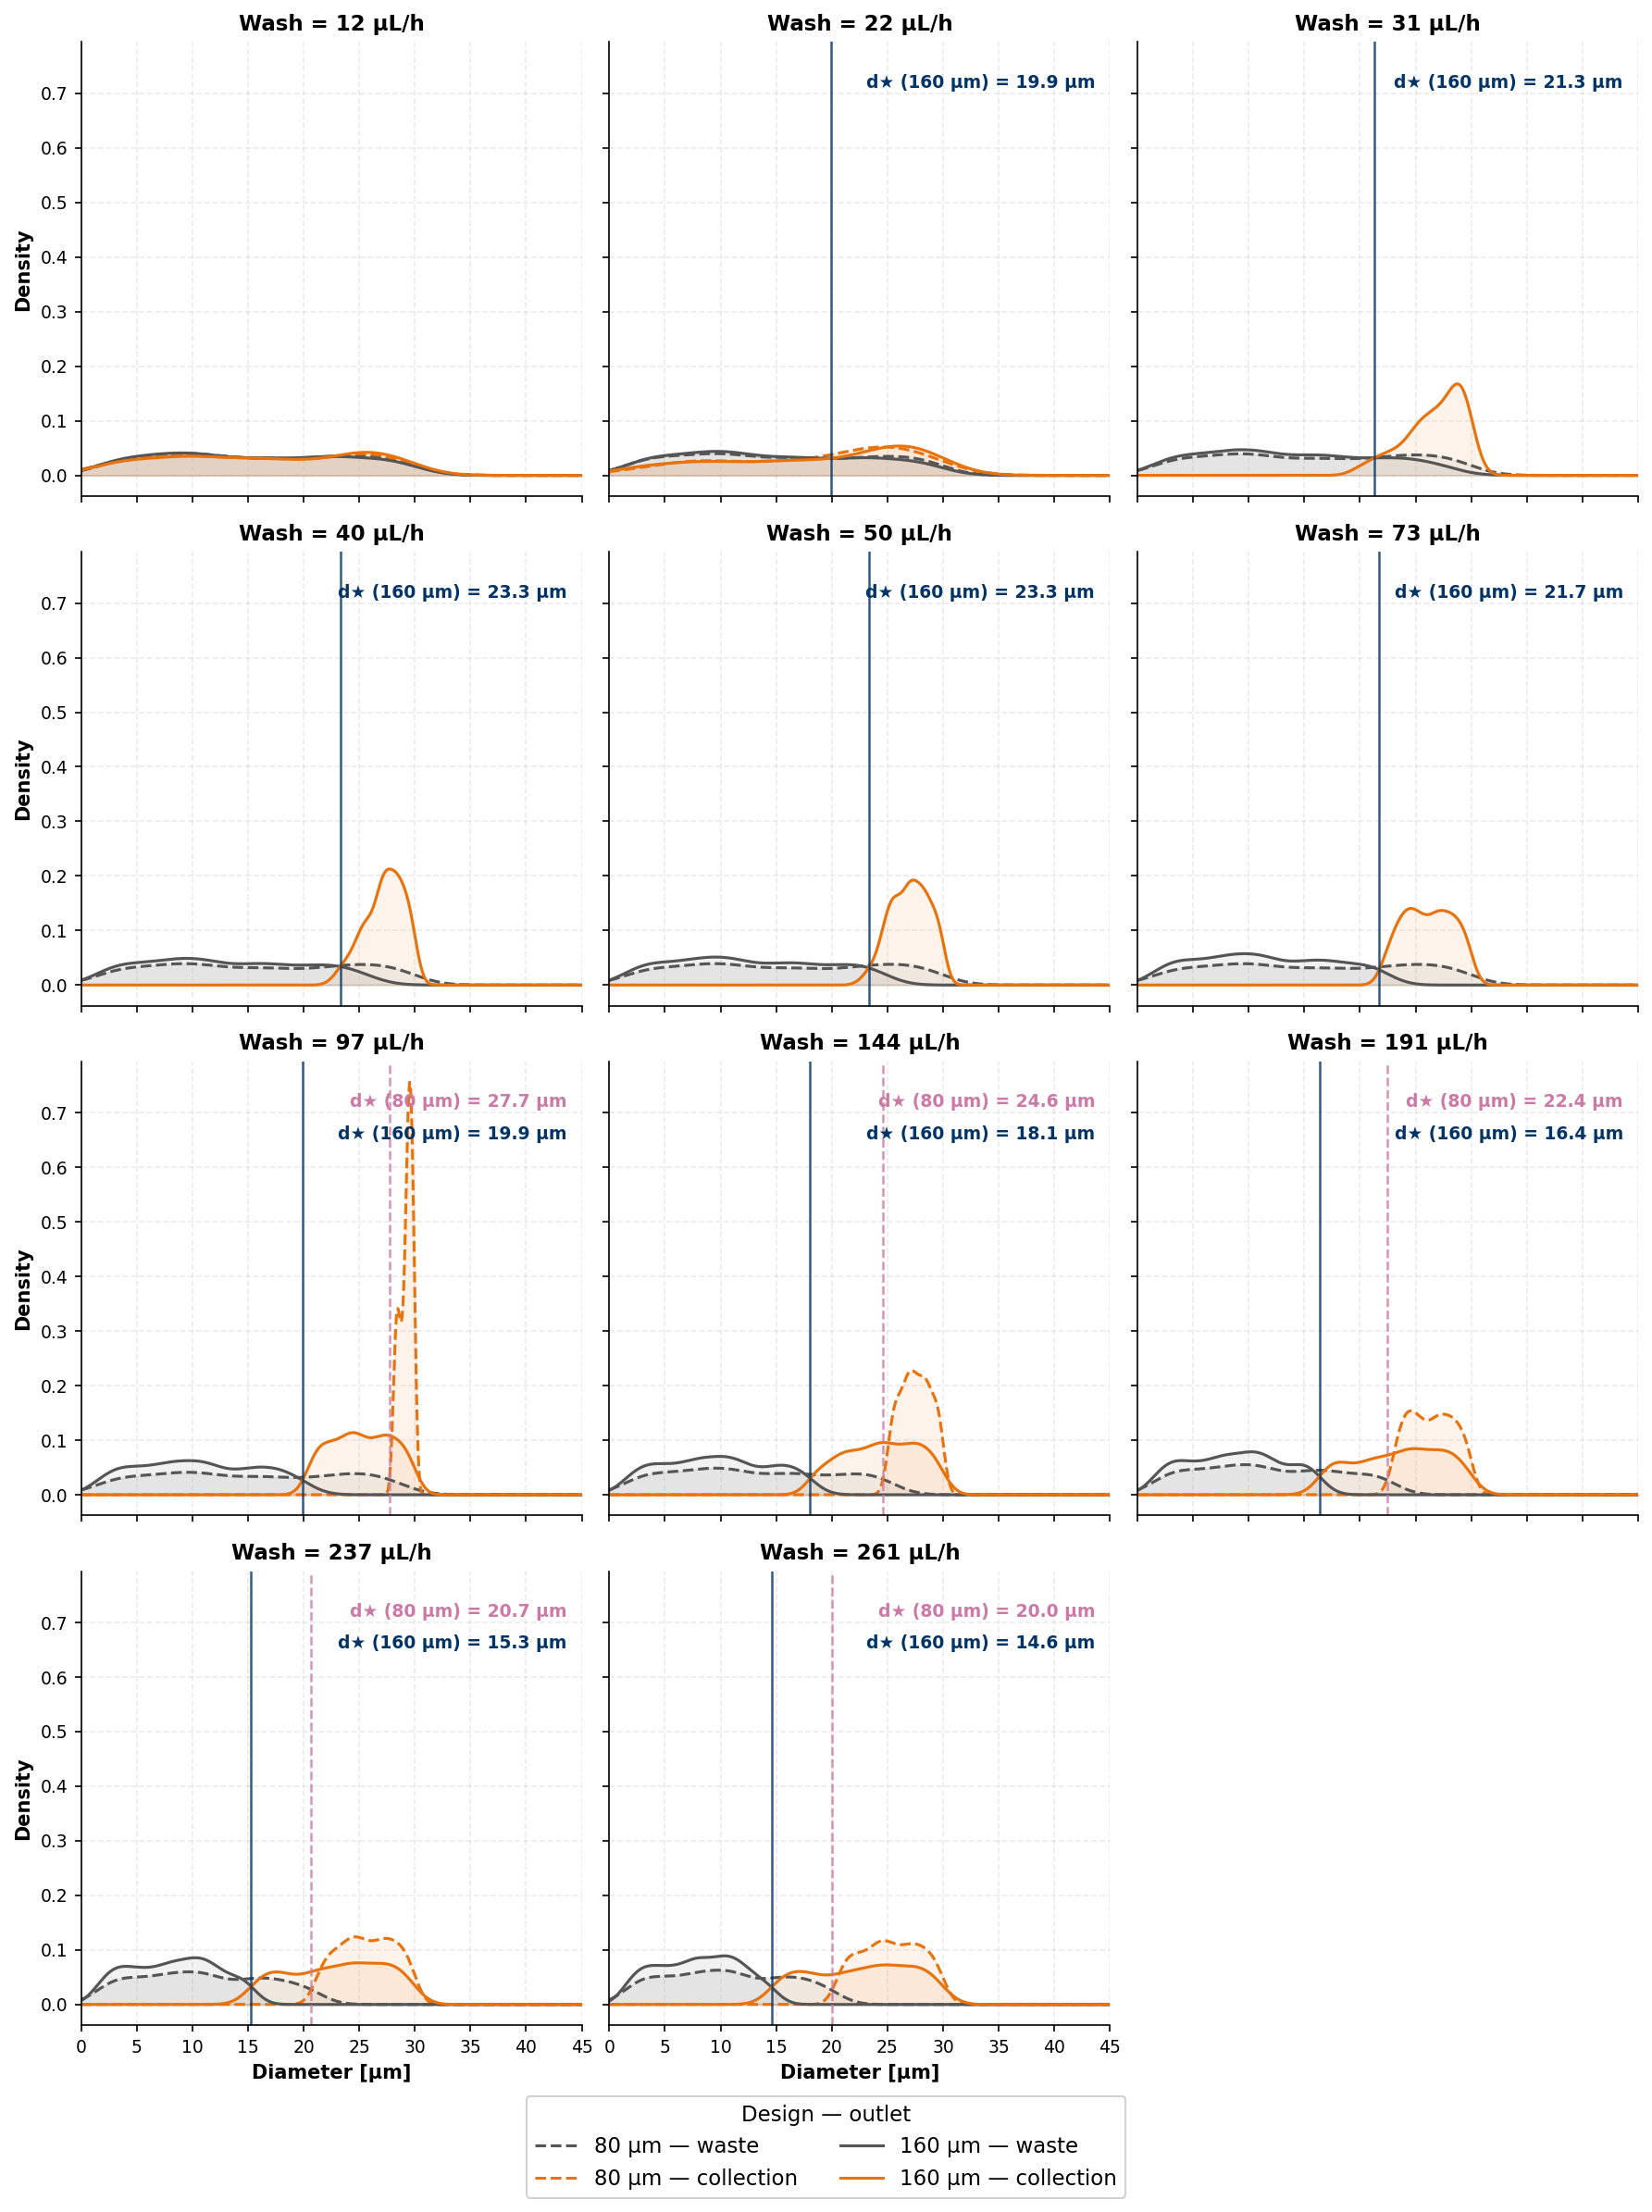

In [ ]:
ncols = 3
nrows = math.ceil(n_rates / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(12, 3.8 * nrows),
    sharex=True, sharey=True
)
axes_flat = np.array(axes).flatten()

x_eval = np.linspace(0, 45, 600)

for idx, v2 in enumerate(wash_rates):
    ax = axes_flat[idx]

    for design in designs:
        ls   = DESIGN_STYLE[design]["linestyle"]
        df_v = comsol_df[
            (comsol_df["design"]    == design) &
            (comsol_df["flow_wash"] == v2)
        ]

        waste = df_v[df_v["outlet"] == 0]["diameter"].values
        coll  = df_v[df_v["outlet"] == 1]["diameter"].values

        if len(waste) > 1:
            kde = gaussian_kde(waste)
            ax.plot(x_eval, kde(x_eval),
                    color=COL_WASTE, linestyle=ls, linewidth=1.5)
            ax.fill_between(x_eval, kde(x_eval), color=COL_WASTE, alpha=0.08)

        if len(coll) > 1:
            kde = gaussian_kde(coll)
            ax.plot(x_eval, kde(x_eval),
                    color=COL_COLLECTION, linestyle=ls, linewidth=1.5)
            ax.fill_between(x_eval, kde(x_eval), color=COL_COLLECTION, alpha=0.08)

    # d★ vertical lines per design, with colour-coded annotation
    dstar_entries = []
    for design in designs:
        row_d = threshold_df[
            (threshold_df["design"]    == design) &
            (threshold_df["flow_wash"] == v2)
        ]
        if not row_d.empty and row_d["d_star"].notna().any() and not row_d["artefact"].values[0]:
            d_val = row_d["d_star"].values[0]
            ax.axvline(
                d_val,
                color=DESIGN_COLOR[design],
                linestyle=DESIGN_STYLE[design]["linestyle"],
                linewidth=1.2, alpha=0.8
            )
            dstar_entries.append((design, d_val))

    # Place d★ values as coloured text in the upper-right corner
    if dstar_entries:
        # White background box (drawn first, behind text)
        ax.text(
            0.97, 0.95,
            "\n".join([" " * 30 for _ in dstar_entries]),  # placeholder for box size
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=9,

            color="none"
        )
        # Coloured text per design, stacked vertically
        for i, (design, d_val) in enumerate(dstar_entries):
            ax.text(
                0.97, 0.93 - i * 0.07,
                f"d★ ({DESIGN_STYLE[design]['label']}) = {d_val:.1f} µm",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=9,
                color=DESIGN_COLOR[design],
                fontweight="bold"
            )
    ax.set_title(f"Wash = {v2} µL/h", fontsize=11, fontweight="bold")
    ax.set_xlim(0, 45)
    ax.tick_params(labelsize=9)

# Remove empty subplots
for ax in axes_flat[n_rates:]:
    fig.delaxes(ax)

# Outer axis labels
for ax in axes_flat[(nrows - 1) * ncols : n_rates]:
    ax.set_xlabel("Diameter [µm]", fontsize=10, fontweight="bold")
for i in range(0, n_rates, ncols):
    axes_flat[i].set_ylabel("Density", fontsize=10, fontweight="bold")

# Shared legend
legend_handles = []
for design in designs:
    ls  = DESIGN_STYLE[design]["linestyle"]
    lbl = DESIGN_STYLE[design]["label"]
    legend_handles += [
        Line2D([0], [0], color=COL_WASTE, linestyle=ls,
               linewidth=1.5, label=f"{lbl} — waste"),
        Line2D([0], [0], color=COL_COLLECTION, linestyle=ls,
               linewidth=1.5, label=f"{lbl} — collection"),
    ]

fig.legend(
    handles=legend_handles,
    loc="lower center", ncol=2,
    bbox_to_anchor=(0.5, -0.05),
    framealpha=0.9,
    title="Design — outlet",
    title_fontsize=11, fontsize=11
)

plt.tight_layout()
plt.savefig("fig_kde_grid.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# ── Compute mean ± SD of diameter in collection outlet ────────────────────────
mean_records = []

for design in designs:
    for v2 in wash_rates:
        df = comsol_df[
            (comsol_df["design"]    == design) &
            (comsol_df["flow_wash"] == v2) &
            (comsol_df["outlet"]    == 1)
        ]

        if len(df) < 2:
            continue

        mean_records.append({
            "design":    design,
            "flow_wash": v2,
            "mean_d":    df["diameter"].mean(),
            "sd_d":      df["diameter"].std(),
            "n":         len(df),
        })

mean_df = pd.DataFrame(mean_records)
mean_df.sort_values(["design", "flow_wash"], inplace=True)
print(mean_df.to_string(index=False))

    design  flow_wash    mean_d     sd_d   n
160um_3out         12 16.460678 8.545196 421
160um_3out         22 18.678038 8.555138 271
160um_3out         31 26.704036 2.596842 154
160um_3out         40 27.261089 1.742796 178
160um_3out         50 27.008986 1.734583 207
160um_3out         73 26.131395 2.187158 288
160um_3out         97 25.219389 2.714247 350
160um_3out        144 24.434909 3.282157 405
160um_3out        191 23.552159 3.876320 464
160um_3out        237 22.944901 4.243121 503
160um_3out        261 22.573854 4.467870 522
 80um_3out         12 15.816262 8.436050 353
 80um_3out         22 18.495077 8.138092 114
 80um_3out         97 29.214202 0.551836  46
 80um_3out        144 27.549721 1.371955 180
 80um_3out        191 26.412906 2.005271 268
 80um_3out        237 25.662413 2.476127 321
 80um_3out        261 25.306994 2.665321 345


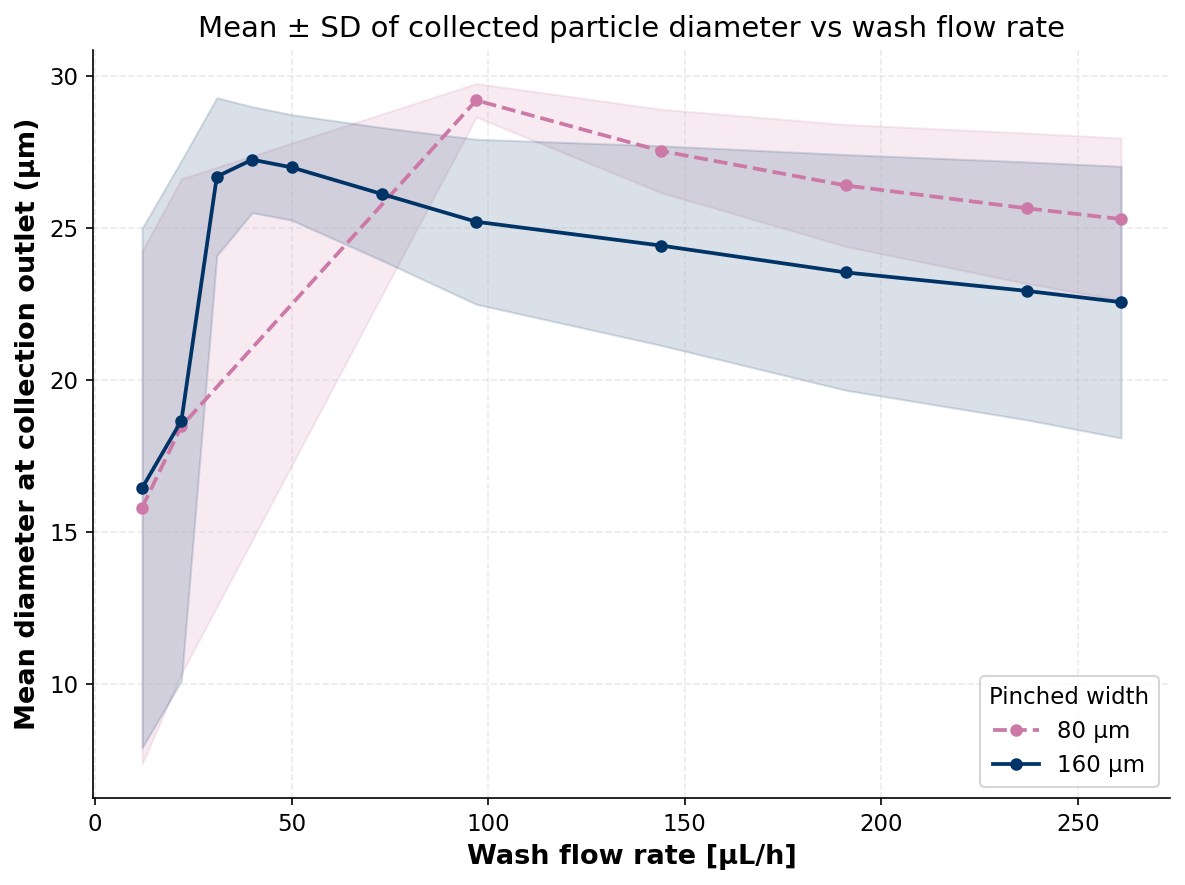

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for design in designs:
    df_d  = mean_df[mean_df["design"] == design]
    color = DESIGN_COLOR[design]
    ls    = DESIGN_STYLE[design]["linestyle"]
    label = DESIGN_STYLE[design]["label"]

    ax.plot(
        df_d["flow_wash"], df_d["mean_d"],
        color=color, linestyle=ls,
        linewidth=1.8, marker="o", markersize=5,
        label=label
    )

    ax.fill_between(
        df_d["flow_wash"],
        df_d["mean_d"] - df_d["sd_d"],
        df_d["mean_d"] + df_d["sd_d"],
        color=color, alpha=0.15
    )

ax.set_xlabel("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean diameter at collection outlet (µm)", fontsize=13, fontweight="bold")
ax.set_title("Mean ± SD of collected particle diameter vs wash flow rate", fontsize=14)
ax.tick_params(labelsize=11)

legend_handles_mean = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8, marker="o", markersize=5,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]
ax.legend(handles=legend_handles_mean, title="Pinched width",
          title_fontsize=11, fontsize=11, framealpha=0.8)

plt.tight_layout()
plt.savefig("fig_mean_diameter_collection.pdf", bbox_inches="tight")
plt.show()

---
## 4. Separation threshold *d★* vs wash flow rate

*d★* is the diameter at which the waste and collection KDE curves intersect — the empirical size cutoff of the device under each flow condition.  
The open circle at 12 µL/h (flow ratio = 1) marks a condition where no productive separation occurs.

In [ ]:
def find_kde_intersection(waste, clean, xmin=0, xmax=None, n=1000):
    """
    Find the first diameter at which the waste and collection KDEs intersect.
    Returns d★ in µm, or None if no intersection is found.
    """
    waste = np.asarray(waste)
    clean = np.asarray(clean)

    if len(waste) < 2 or len(clean) < 2:
        return None

    if xmax is None:
        xmax = max(waste.max(), clean.max())

    kde_w = gaussian_kde(waste)
    kde_c = gaussian_kde(clean)

    x    = np.linspace(xmin, xmax, n)
    diff = kde_w(x) - kde_c(x)

    sign_changes = np.where(np.diff(np.sign(diff)))[0]

    if len(sign_changes) == 0:
        return None

    # Linear interpolation around the first sign change
    i      = sign_changes[0]
    x0, x1 = x[i], x[i + 1]
    y0, y1 = diff[i], diff[i + 1]
    d_star = x0 - y0 * (x1 - x0) / (y1 - y0)

    return d_star

In [ ]:
x_eval = np.linspace(0, 45, 1000)

threshold_records = []

for design in designs:
    for v2 in wash_rates:
        df = comsol_df[
            (comsol_df["design"]    == design) &
            (comsol_df["flow_wash"] == v2)
        ]

        waste = df[df["outlet"] == 0]["diameter"].values
        coll  = df[df["outlet"] == 1]["diameter"].values

        # Always compute d★; artefact flag controls visual style only
        d_star   = find_kde_intersection(waste, coll)
        artefact = (v2 == ARTEFACT_FLOW)

        # Artefacts: conditions where d★ is not physically meaningful
        # (no productive separation occurring)
        is_artefact = (
            (v2 == 12) or
            (design == "80um_3out" and v2 in (22, 31))
        )

        threshold_records.append({
            "design":    design,
            "flow_wash": v2,
            "d_star":    d_star,
            "artefact":  is_artefact,
        })

threshold_df = pd.DataFrame(threshold_records)
threshold_df.sort_values(["design", "flow_wash"], inplace=True)
print(threshold_df.to_string(index=False))

    design  flow_wash    d_star  artefact
160um_3out         12  0.332845      True
160um_3out         22 19.897030     False
160um_3out         31 21.274917     False
160um_3out         40 23.291428     False
160um_3out         50 23.307618     False
160um_3out         73 21.714236     False
160um_3out         97 19.888453     False
160um_3out        144 18.057589     False
160um_3out        191 16.351366     False
160um_3out        237 15.277059     False
160um_3out        261 14.583423     False
 80um_3out         12  4.362614      True
 80um_3out         22 18.067454      True
 80um_3out         31       NaN      True
 80um_3out         40       NaN     False
 80um_3out         50       NaN     False
 80um_3out         73       NaN     False
 80um_3out         97 27.710159     False
 80um_3out        144 24.594846     False
 80um_3out        191 22.413688     False
 80um_3out        237 20.677181     False
 80um_3out        261 20.002432     False


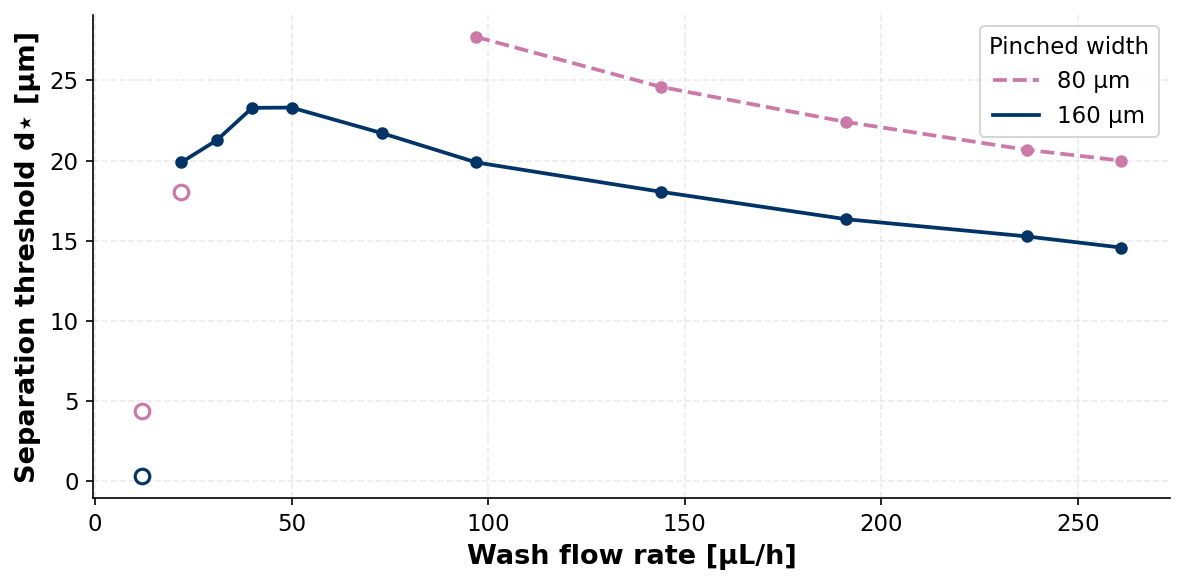

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

for design in designs:
    df_d  = threshold_df[threshold_df["design"] == design].sort_values("flow_wash")
    color = DESIGN_COLOR[design]
    ls    = DESIGN_STYLE[design]["linestyle"]
    label = DESIGN_STYLE[design]["label"]

    valid = df_d[~df_d["artefact"] & df_d["d_star"].notna()]
    art   = df_d[df_d["artefact"]   & df_d["d_star"].notna()]

    # Valid points: connected by the line
    ax.plot(
        valid["flow_wash"], valid["d_star"],
        color=color, linestyle=ls, linewidth=1.8,
        marker="o", markersize=5, label=label
    )

    # Artefact points: open circles, no connecting line
    if not art.empty:
        ax.plot(
            art["flow_wash"], art["d_star"],
            marker="o", markersize=7,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=1.5,
            linestyle="none"
        )

ax.set_xlabel("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
ax.set_ylabel("Separation threshold d⋆ [µm]", fontsize=13, fontweight="bold")
ax.tick_params(labelsize=11)

legend_handles = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]
ax.legend(handles=legend_handles, title="Pinched width",
          title_fontsize=11, fontsize=11, framealpha=0.8)

plt.tight_layout()
plt.savefig("fig_dstar_vs_flowrate.pdf", bbox_inches="tight")
plt.show()

---
## 5. Separation metrics vs wash flow rate

Three metrics are computed and plotted separately:
- **Recovery** — fraction of true GUVs collected: ${Recovery} = TP / (TP + FN)$
- **Purity** — fraction of collected particles that are true GUVs: ${Purity} = TP / (TP + FP)$
- **Separation efficiency** — combined metric: ${Efficiency} = {Recovery} * {Purity}$
- **Enrichment factor** — ratio of GUV fraction in the collection outlet to GUV fraction in the original sample: $$EF=GUV~(collection) / GUV~(original~sample) = [TP/(TP+FP)]~(purity) / [(TP+FN)/N_t]$$

Two GUV size definitions are evaluated:
- **Case 1**: GUV if diameter > 10 µm
- **Case 2**: GUV if diameter > 15 µm

In [ ]:
def compute_metrics(df, guv_threshold):
    """
    Compute recovery, purity, and separation efficiency.

    Parameters
    ----------
    df : DataFrame
        Subset for one design x wash flow rate combination.
        Must contain columns: 'diameter', 'outlet' (0=waste, 1=collection).
    guv_threshold : float
        Minimum diameter (µm) for a particle to be classified as a GUV.

    Returns
    -------
    dict with keys: recovery, purity, separation_eff
    """
    df = df.copy()
    df["is_GUV"] = df["diameter"] > guv_threshold

    collection = df[df["outlet"] == 1]
    waste      = df[df["outlet"] == 0]

    TP = collection[collection["is_GUV"]].shape[0]    # GUVs in collection
    FN = waste[waste["is_GUV"]].shape[0]              # GUVs lost to waste
    FP = collection[~collection["is_GUV"]].shape[0]   # non-GUVs in collection

    if (TP + FN) == 0 or (TP + FP) == 0:
        return None

    recovery       = TP / (TP + FN)
    purity         = TP / (TP + FP)
    separation_eff = recovery * purity

    return {"recovery": recovery, "purity": purity, "separation_eff": separation_eff}

In [ ]:
def compute_metrics(df, guv_threshold):
    """
    Compute recovery, purity, separation efficiency, and enrichment factor.

    Parameters
    ----------
    df : DataFrame
        Subset for one design x wash flow rate combination.
        Must contain columns: 'diameter', 'outlet' (0=waste, 1=collection).
    guv_threshold : float
        Minimum diameter (µm) for a particle to be classified as a GUV.

    Returns
    -------
    dict with keys: recovery, purity, separation_eff, enrichment_factor
    """
    df = df.copy()
    df["is_GUV"] = df["diameter"] > guv_threshold

    collection = df[df["outlet"] == 1]
    waste      = df[df["outlet"] == 0]

    TP = collection[collection["is_GUV"]].shape[0]    # GUVs in collection
    FN = waste[waste["is_GUV"]].shape[0]              # GUVs lost to waste
    FP = collection[~collection["is_GUV"]].shape[0]   # non-GUVs in collection
    N  = len(df)                                       # total particles

    if (TP + FN) == 0 or (TP + FP) == 0 or N == 0:
        return None

    recovery           = TP / (TP + FN)
    purity             = TP / (TP + FP)
    separation_eff     = recovery * purity
    guv_fraction_input = (TP + FN) / N
    enrichment_factor  = purity / guv_fraction_input

    return {
        "recovery":           recovery,
        "purity":             purity,
        "separation_eff":     separation_eff,
        "enrichment_factor":  enrichment_factor,
    }

In [ ]:
GUV_THRESHOLDS = {
    "Case 1 (> 10 µm)": 10,
    "Case 2 (> 15 µm)": 15,
}

metrics_records = []

for case_label, guv_thr in GUV_THRESHOLDS.items():
    for design in designs:
        for v2 in wash_rates:
            df = comsol_df[
                (comsol_df["design"]    == design) &
                (comsol_df["flow_wash"] == v2)
            ]
            m = compute_metrics(df, guv_thr)
            if m is None:
                continue
            metrics_records.append({
                "case": case_label, "guv_threshold": guv_thr,
                "design": design,  "flow_wash": v2, **m,
            })

metrics_df = pd.DataFrame(metrics_records)
metrics_df.sort_values(["case", "design", "flow_wash"], inplace=True)
print(metrics_df.to_string(index=False))

            case  guv_threshold     design  flow_wash  recovery   purity  separation_eff  enrichment_factor
Case 1 (> 10 µm)             10 160um_3out         12  0.438416 0.710214        0.311369           1.025749
Case 1 (> 10 µm)             10 160um_3out         22  0.308588 0.782288        0.241405           1.121621
Case 1 (> 10 µm)             10 160um_3out         31  0.225476 1.000000        0.225476           1.443631
Case 1 (> 10 µm)             10 160um_3out         40  0.261380 1.000000        0.261380           1.447871
Case 1 (> 10 µm)             10 160um_3out         50  0.303965 1.000000        0.303965           1.449339
Case 1 (> 10 µm)             10 160um_3out         73  0.420438 1.000000        0.420438           1.440876
Case 1 (> 10 µm)             10 160um_3out         97  0.511696 1.000000        0.511696           1.442982
Case 1 (> 10 µm)             10 160um_3out        144  0.593842 1.000000        0.593842           1.447214
Case 1 (> 10 µm)            

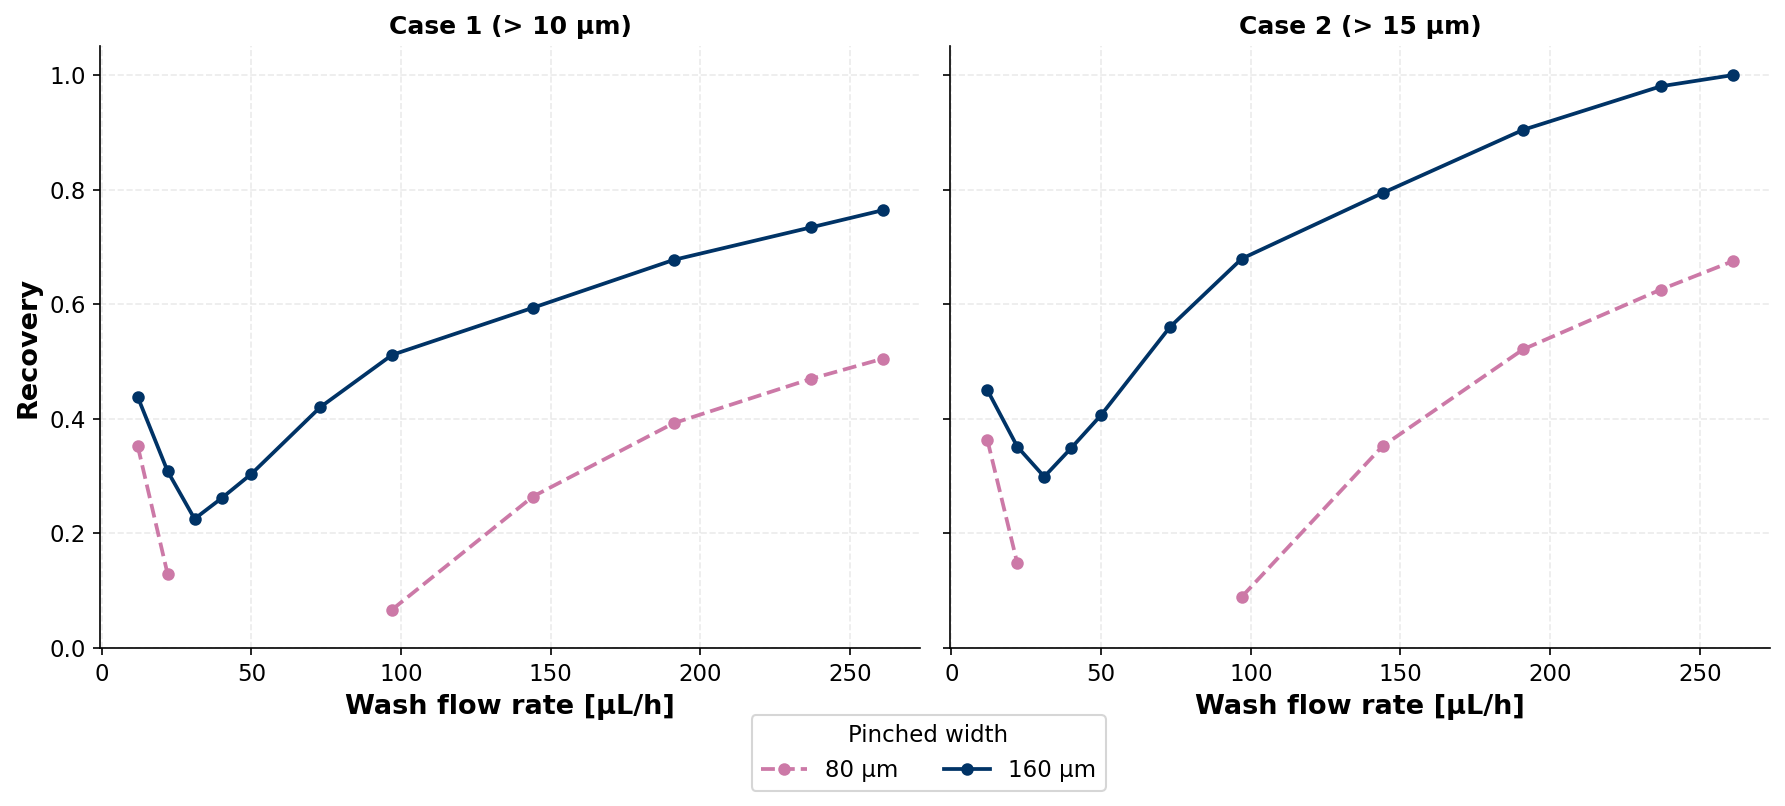

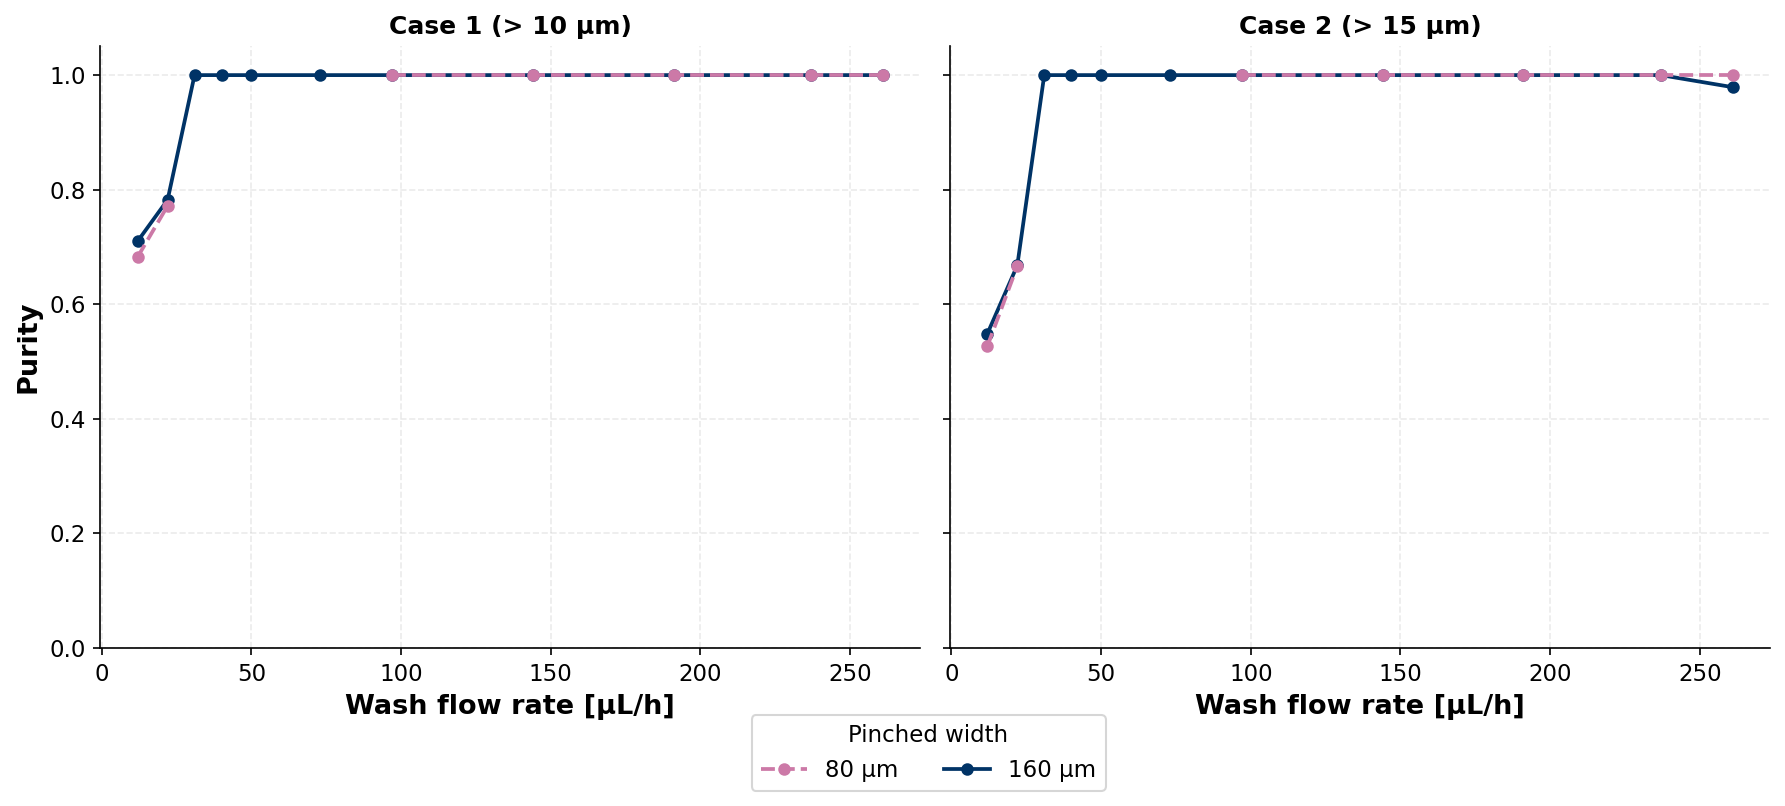

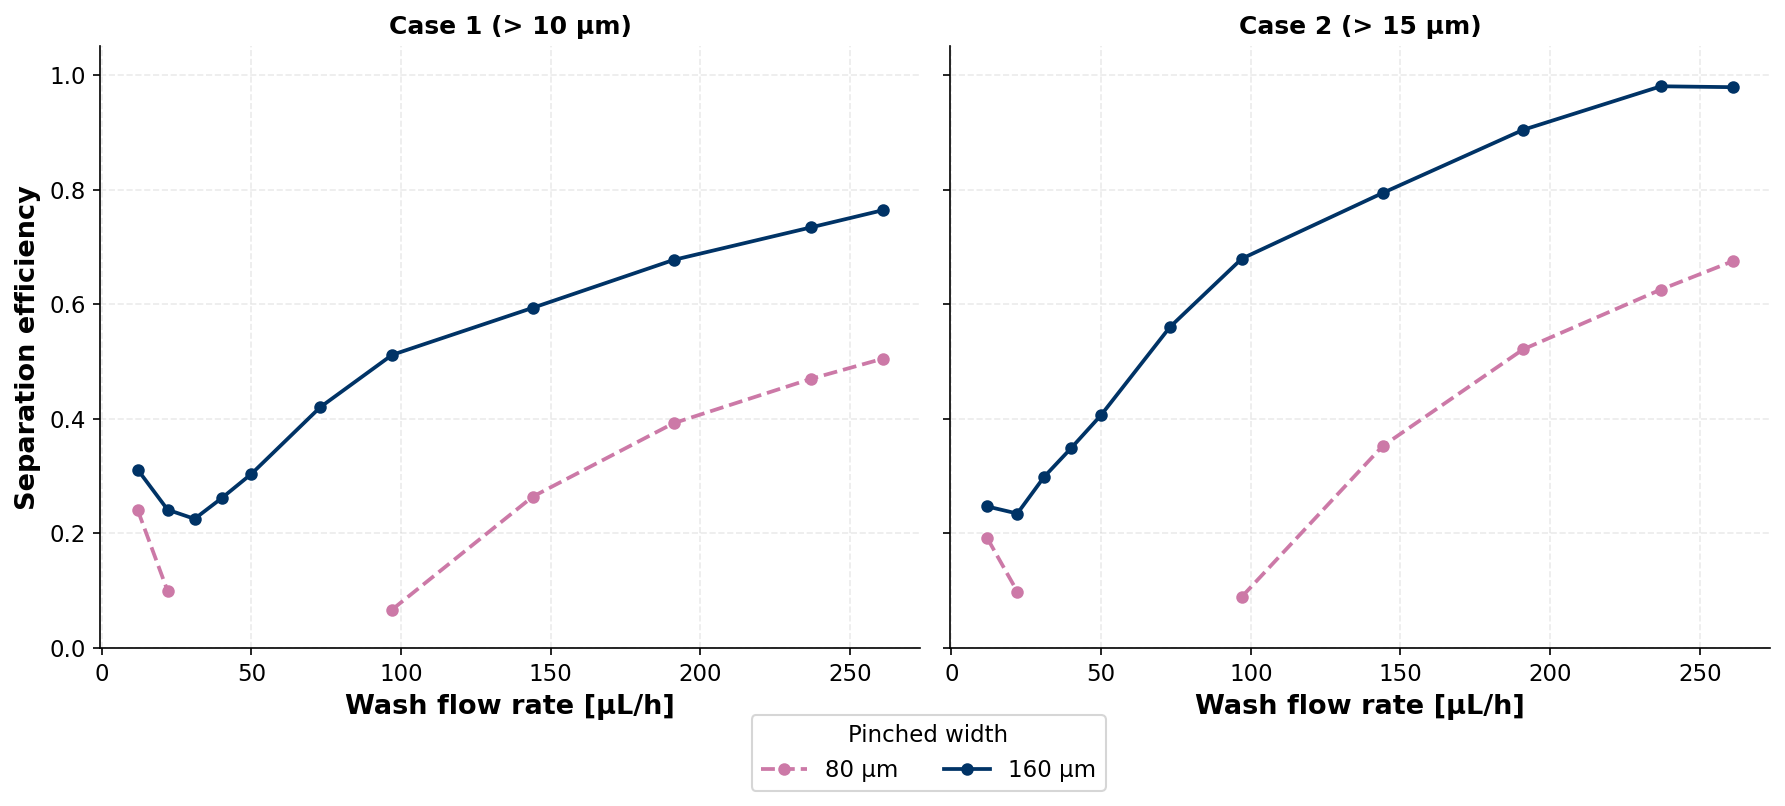

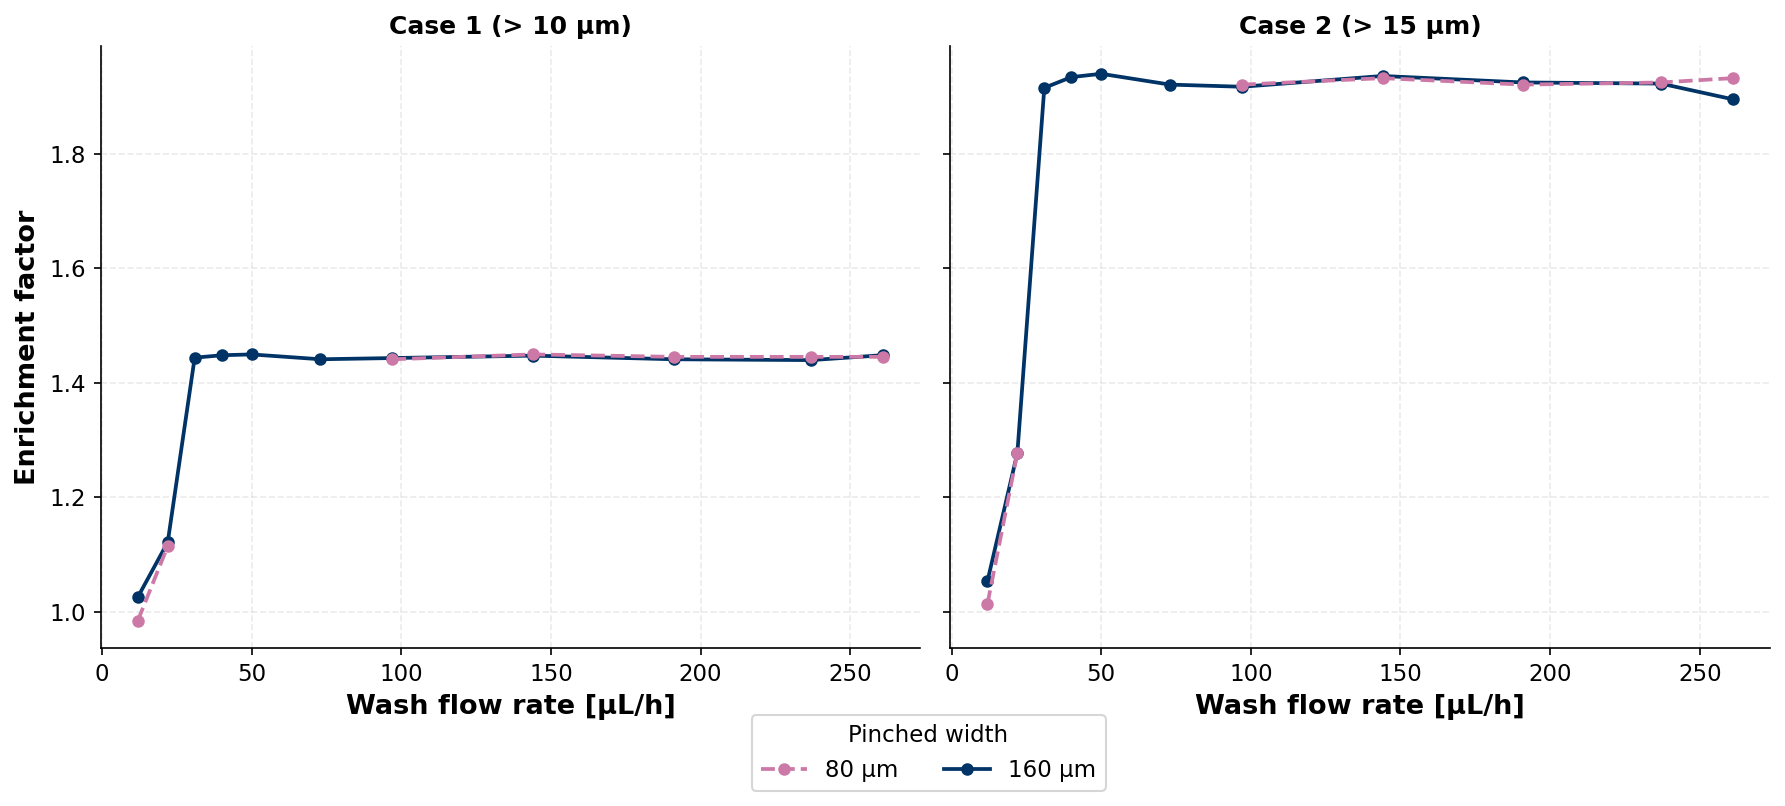

In [ ]:
cases         = list(GUV_THRESHOLDS.keys())
metric_cols   = ["recovery", "purity", "separation_eff", "enrichment_factor"]
metric_labels = {
    "recovery":          "Recovery",
    "purity":            "Purity",
    "separation_eff":    "Separation efficiency",
    "enrichment_factor": "Enrichment factor",
}

# Flow rates where the 80 µm design produces no collection at all
NO_COLLECTION = {
    "80um_3out":  [40, 50],
    "160um_3out": [],
}

legend_handles = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8, marker="o", markersize=5,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]

for metric in metric_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, case in zip(axes, cases):
        df_case = metrics_df[metrics_df["case"] == case]

        for design in reversed(designs):
            df_d   = df_case[df_case["design"] == design].sort_values("flow_wash")
            color  = DESIGN_COLOR[design]
            ls     = DESIGN_STYLE[design]["linestyle"]
            gap    = NO_COLLECTION[design]

            if not gap:
                # No gap — plot as a single continuous line
                ax.plot(
                    df_d["flow_wash"], df_d[metric],
                    color=color, linestyle=ls,
                    linewidth=1.8, marker="o", markersize=5
                )
            else:
                # Split into segments around the gap
                df_before = df_d[df_d["flow_wash"] < min(gap)]
                df_after  = df_d[df_d["flow_wash"] > max(gap)]
                for seg in (df_before, df_after):
                    if not seg.empty:
                        ax.plot(
                            seg["flow_wash"], seg[metric],
                            color=color, linestyle=ls,
                            linewidth=1.8, marker="o", markersize=5
                        )

        ax.set_title(case, fontsize=12, fontweight="bold")
        ax.set_xlabel("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
        ax.tick_params(labelsize=11)

        if metric != "enrichment_factor":
            ax.set_ylim(0, 1.05)

    axes[0].set_ylabel(metric_labels[metric], fontsize=13, fontweight="bold")

    fig.legend(
        handles=legend_handles,
        title="Pinched width",
        title_fontsize=11, fontsize=11,
        framealpha=0.8,
        loc="lower center",
        ncol=len(designs),
        bbox_to_anchor=(0.52, -0.08)
    )

    plt.tight_layout()
    plt.savefig(f"fig_{metric}.pdf", bbox_inches="tight")
    plt.show()

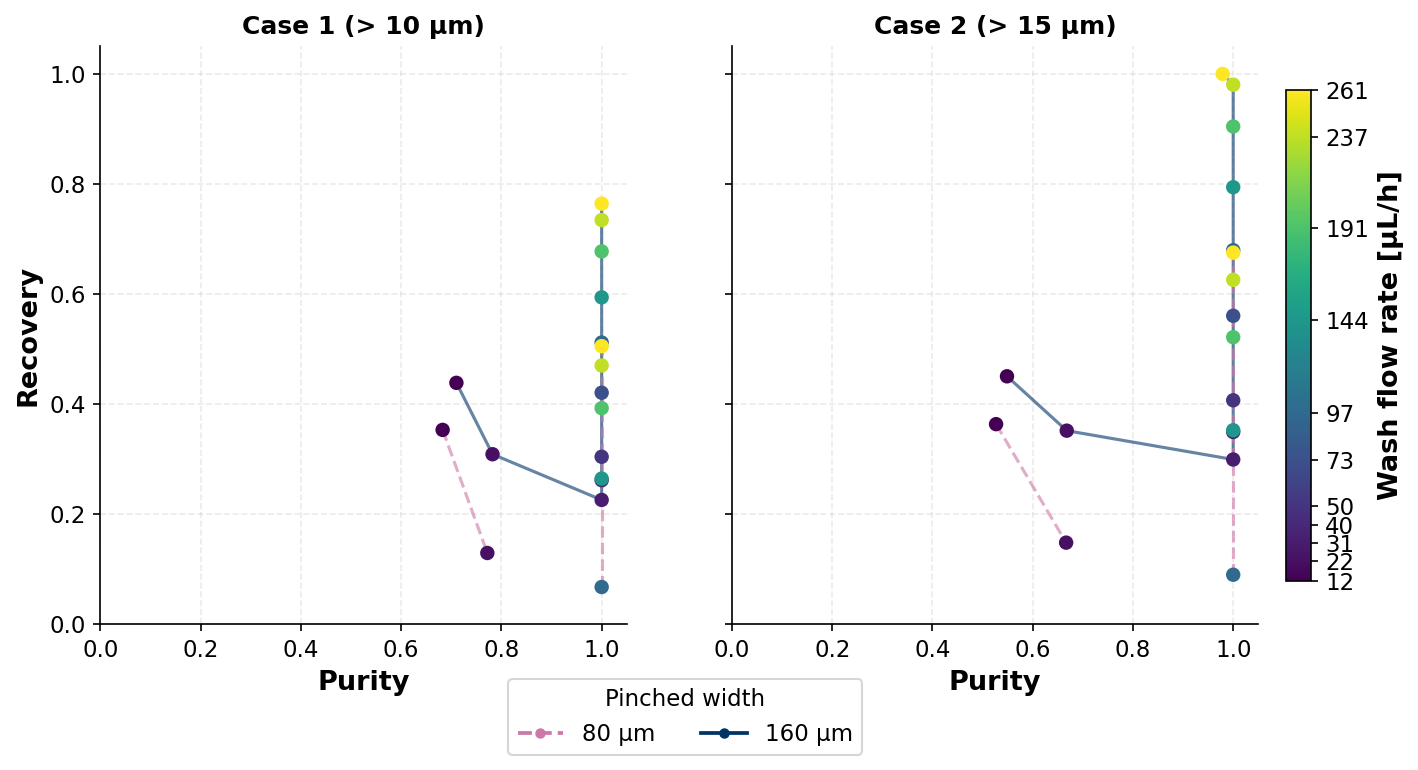

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, sharex=True)

NO_COLLECTION = {
    "80um_3out":  [40, 50],
    "160um_3out": [],
}

for ax, case in zip(axes, cases):
    df_case = metrics_df[metrics_df["case"] == case]

    for design in reversed(designs):
        df_d = df_case[df_case["design"] == design].sort_values("flow_wash")
        gap  = NO_COLLECTION[design]

        # Scatter all points
        sc = ax.scatter(
            df_d["purity"], df_d["recovery"],
            c=df_d["flow_wash"],
            cmap="viridis",
            vmin=min(wash_rates), vmax=max(wash_rates),
            s=35, zorder=3
        )

        # Connecting line: split around the gap if needed
        if not gap:
            ax.plot(
                df_d["purity"], df_d["recovery"],
                color=DESIGN_COLOR[design],
                linestyle=DESIGN_STYLE[design]["linestyle"],
                linewidth=1.5, alpha=0.6, zorder=2
            )
        else:
            df_before = df_d[df_d["flow_wash"] < min(gap)]
            df_after  = df_d[df_d["flow_wash"] > max(gap)]
            for seg in (df_before, df_after):
                if len(seg) > 1:
                    ax.plot(
                        seg["purity"], seg["recovery"],
                        color=DESIGN_COLOR[design],
                        linestyle=DESIGN_STYLE[design]["linestyle"],
                        linewidth=1.5, alpha=0.6, zorder=2
                    )

    ax.set_title(case, fontsize=12, fontweight="bold")
    ax.set_xlabel("Purity", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.tick_params(labelsize=11)

axes[0].set_ylabel("Recovery", fontsize=13, fontweight="bold")

sm = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(vmin=min(wash_rates), vmax=max(wash_rates))
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, pad=0.02, shrink=0.85)
cbar.set_label("Wash flow rate [µL/h]", fontsize=13, fontweight="bold")
cbar.set_ticks(wash_rates)
cbar.ax.tick_params(labelsize=11)

legend_handles_pr = [
    Line2D([0], [0], color=DESIGN_COLOR[d],
           linestyle=DESIGN_STYLE[d]["linestyle"],
           linewidth=1.8, marker="o", markersize=4,
           label=DESIGN_STYLE[d]["label"])
    for d in designs
]
fig.legend(
    handles=legend_handles_pr,
    title="Pinched width",
    title_fontsize=11, fontsize=11,
    framealpha=0.8,
    loc="lower center",
    ncol=len(designs),
    bbox_to_anchor=(0.45, -0.08)
)

#plt.tight_layout()
plt.savefig("fig_purity_vs_recovery.pdf", bbox_inches="tight")
plt.show()

---
## 6. Export summary tables

In [ ]:
OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/MEP")

threshold_df.to_csv(OUTPUT_DIR / "comsol_thresholds_1010density.csv", index=False)
metrics_df.to_csv(OUTPUT_DIR   / "comsol_metrics_1010density.csv",    index=False)

print("Saved:")
print(f"  {OUTPUT_DIR / 'comsol_thresholds_1010density.csv'}")
print(f"  {OUTPUT_DIR / 'comsol_metrics_1010density.csv'}")